In [11]:
import pandas as pd

df = pd.read_csv("../data/raw/application_train.csv")

In [12]:
print(df.shape)

print(df["TARGET"].value_counts())

print(df["TARGET"].value_counts(normalize=True))

(307511, 122)
TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [ ]:
** The part for EDA chart is in the next notebook.**

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [16]:
df = pd.read_csv("../data/raw/application_train.csv")

df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
import os

os.makedirs("../assets/charts", exist_ok=True)

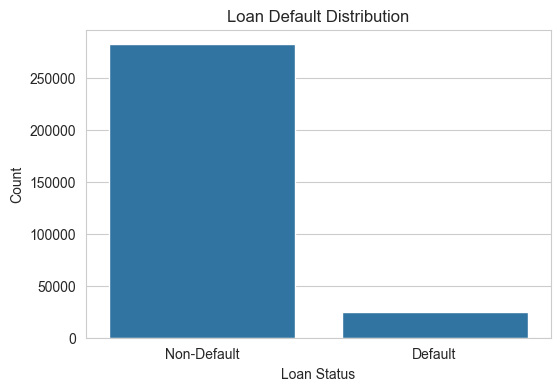

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(x="TARGET", data=df)

plt.title("Loan Default Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.xticks([0,1], ["Non-Default", "Default"])

plt.savefig("../assets/charts/target_distribution.png")

plt.show()

In [19]:
print("""
Business Insight:
The dataset is highly imbalanced, with most applicants belonging to the non-default category. 
This imbalance must be addressed during model training to avoid biased predictions.
""")


Business Insight:
The dataset is highly imbalanced, with most applicants belonging to the non-default category. 
This imbalance must be addressed during model training to avoid biased predictions.



In [20]:
missing = df.isnull().mean() * 100

missing = missing.sort_values(ascending=False)

missing.head(20)

COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
FLOORSMIN_AVG               67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
LANDAREA_AVG                59.376738
dtype: float64

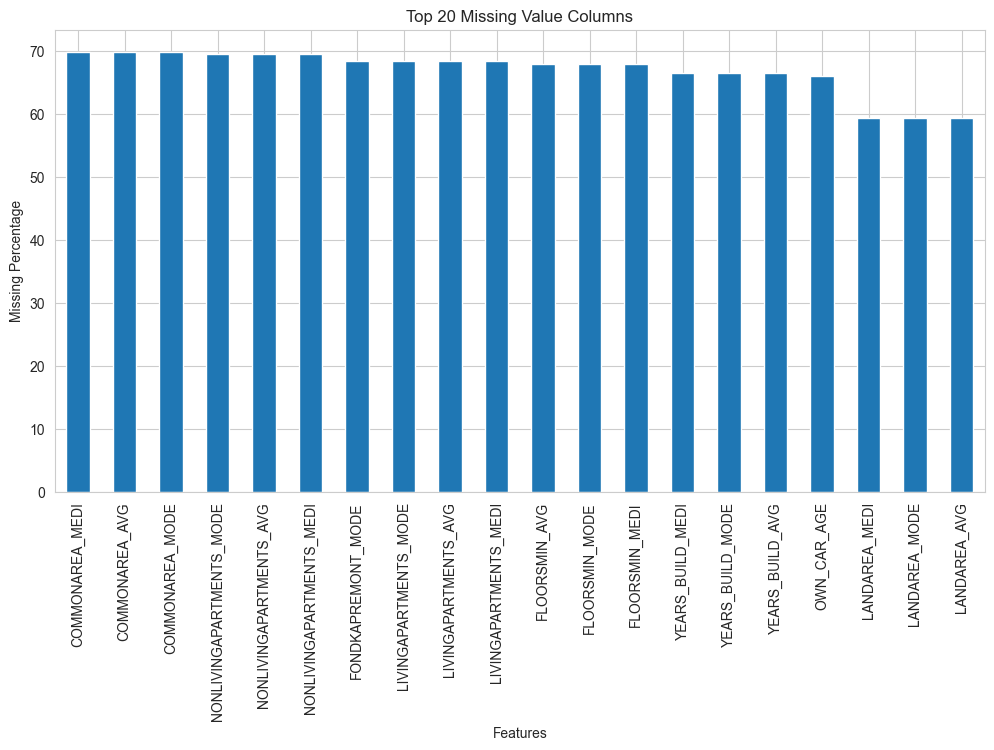


Business Insight:
Several housing and external credit-related features contain substantial missing values, 
indicating incomplete customer information and inconsistent reporting patterns.



In [23]:
top_missing = missing.head(20)

plt.figure(figsize=(12,6))

top_missing.plot(kind="bar")

plt.title("Top 20 Missing Value Columns")
plt.xlabel("Features")
plt.ylabel("Missing Percentage")

plt.savefig("../assets/charts/missing_values.png")

plt.show()

print("""
Business Insight:
Several housing and external credit-related features contain substantial missing values, 
indicating incomplete customer information and inconsistent reporting patterns.
""")

In [24]:
df["AGE"] = abs(df["DAYS_BIRTH"]) / 365

/var/folders/zl/6dwxxfl91wgf183y1zsxyhym0000gn/T/ipykernel_4936/2583455205.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["AGE"] = abs(df["DAYS_BIRTH"]) / 365


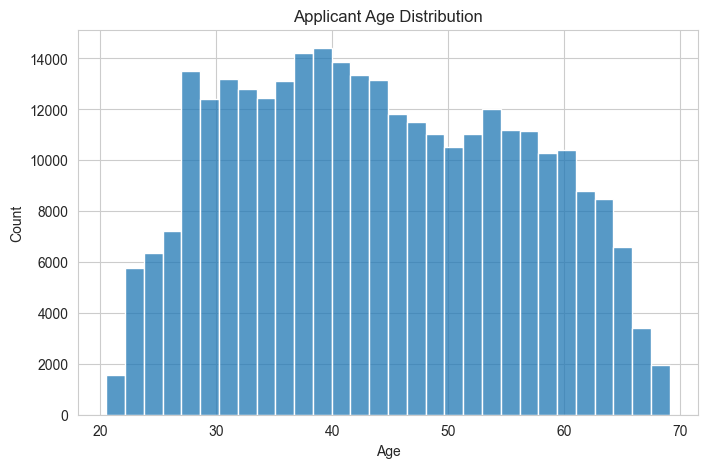

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df["AGE"], bins=30)

plt.title("Applicant Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.savefig("../assets/charts/age_distribution.png")

plt.show()

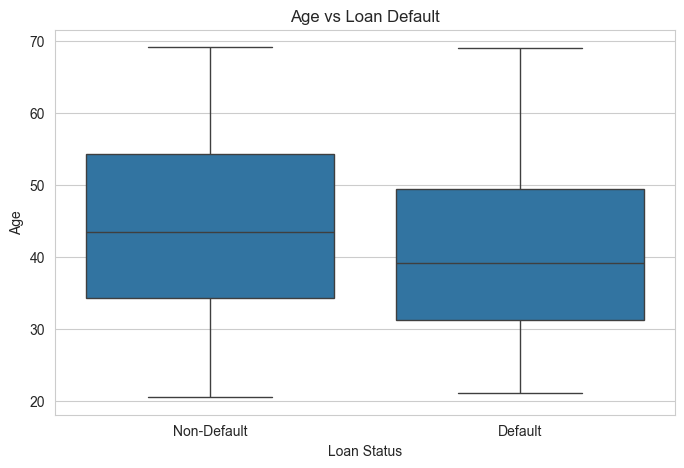


Business Insight:
Younger applicants exhibit slightly higher default tendencies compared to older applicants, 
possibly due to lower financial stability and shorter credit history.



In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(x="TARGET", y="AGE", data=df)

plt.title("Age vs Loan Default")
plt.xlabel("Loan Status")
plt.ylabel("Age")

plt.xticks([0,1], ["Non-Default", "Default"])

plt.savefig("../assets/charts/age_vs_default.png")

plt.show()

print("""
Business Insight:
Younger applicants exhibit slightly higher default tendencies compared to older applicants, 
possibly due to lower financial stability and shorter credit history.
""")

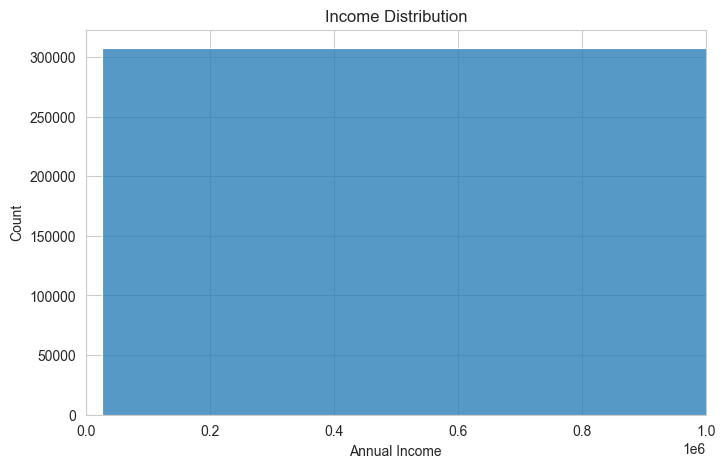

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(df["AMT_INCOME_TOTAL"], bins=50)

plt.xlim(0, 1000000)

plt.title("Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Count")

plt.savefig("../assets/charts/income_distribution.png")

plt.show()

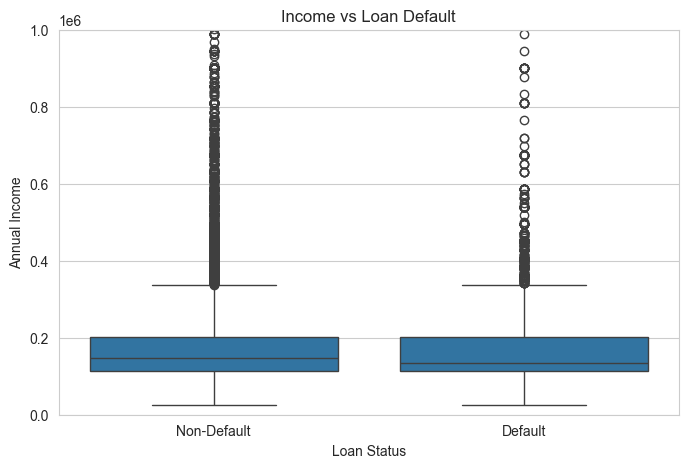


Business Insight:
Applicants with lower income levels tend to exhibit higher default probability, 
suggesting financial capacity plays a major role in repayment behavior.



In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(x="TARGET", y="AMT_INCOME_TOTAL", data=df)

plt.ylim(0, 1000000)

plt.title("Income vs Loan Default")
plt.xlabel("Loan Status")
plt.ylabel("Annual Income")

plt.xticks([0,1], ["Non-Default", "Default"])

plt.savefig("../assets/charts/income_vs_default.png")

plt.show()

print("""
Business Insight:
Applicants with lower income levels tend to exhibit higher default probability, 
suggesting financial capacity plays a major role in repayment behavior.
""")

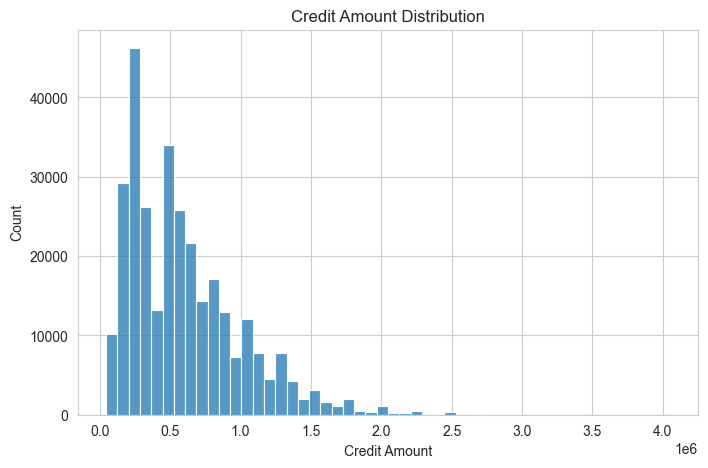

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(df["AMT_CREDIT"], bins=50)

plt.title("Credit Amount Distribution")
plt.xlabel("Credit Amount")
plt.ylabel("Count")

plt.savefig("../assets/charts/credit_distribution.png")

plt.show()

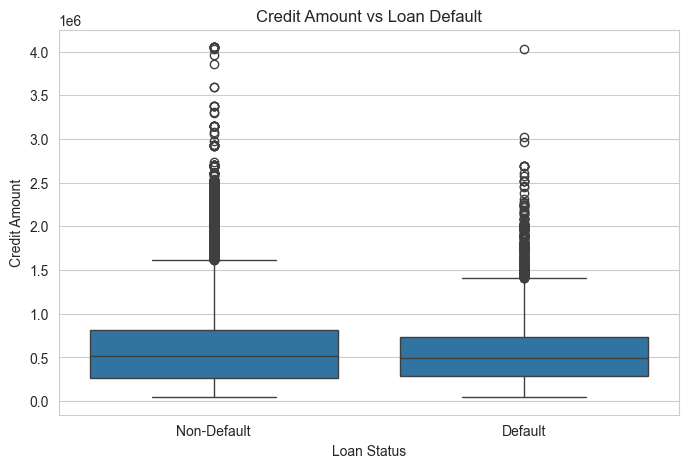


Business Insight:
Applicants with higher credit amounts tend to exhibit increased repayment risk, 
highlighting the importance of exposure-based risk assessment.



In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(x="TARGET", y="AMT_CREDIT", data=df)

plt.title("Credit Amount vs Loan Default")
plt.xlabel("Loan Status")
plt.ylabel("Credit Amount")

plt.xticks([0,1], ["Non-Default", "Default"])

plt.savefig("../assets/charts/credit_vs_default.png")

plt.show()

print("""
Business Insight:
Applicants with higher credit amounts tend to exhibit increased repayment risk, 
highlighting the importance of exposure-based risk assessment.
""")

HeatMap

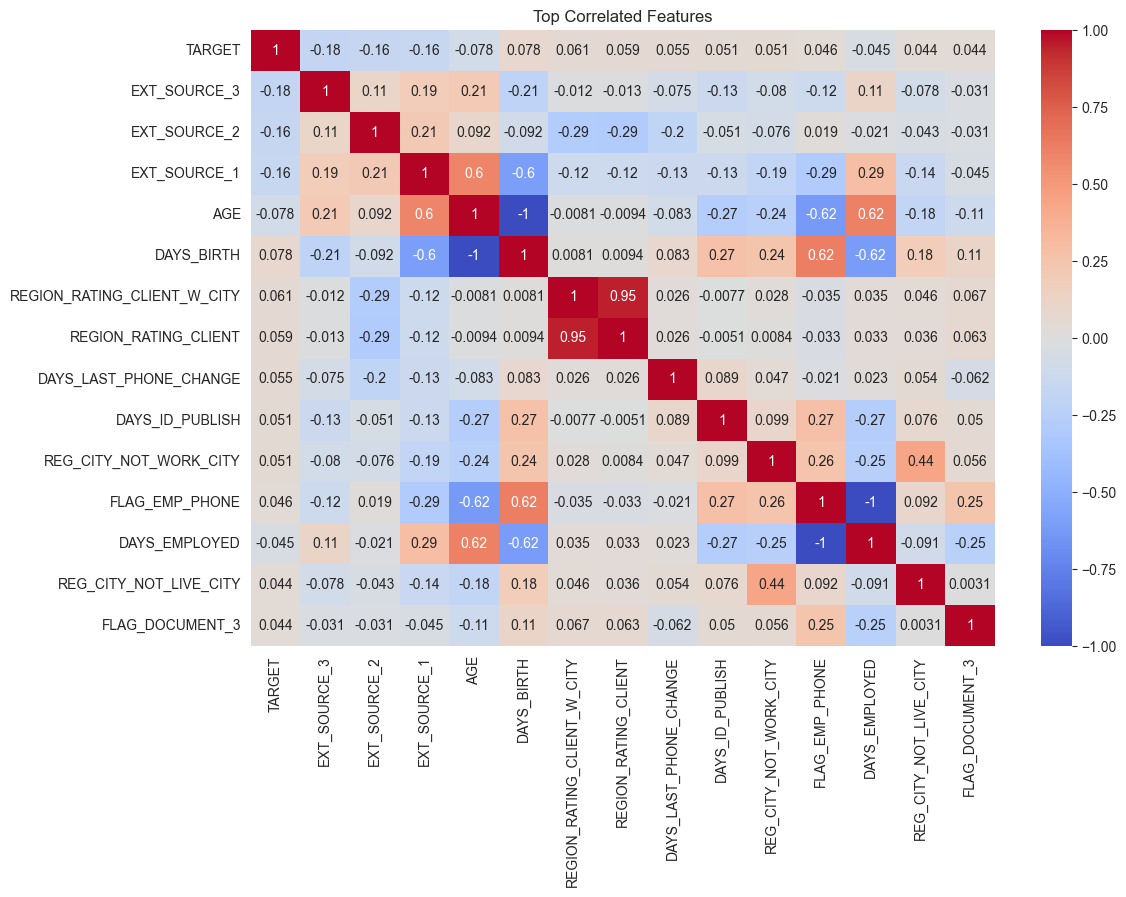


Business Insight:
External credit score features and customer repayment history variables show strong relationships 
with loan default risk, making them valuable predictors for credit scoring models.



In [34]:
numeric_df = df.select_dtypes(include=[np.number])

corr = numeric_df.corr()["TARGET"].abs().sort_values(ascending=False)

corr.head(15)

top_features = corr.head(15).index

top_features

plt.figure(figsize=(12,8))

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Top Correlated Features")

plt.savefig("../assets/charts/correlation_heatmap.png")

plt.show()

print("""
Business Insight:
External credit score features and customer repayment history variables show strong relationships 
with loan default risk, making them valuable predictors for credit scoring models.
""")

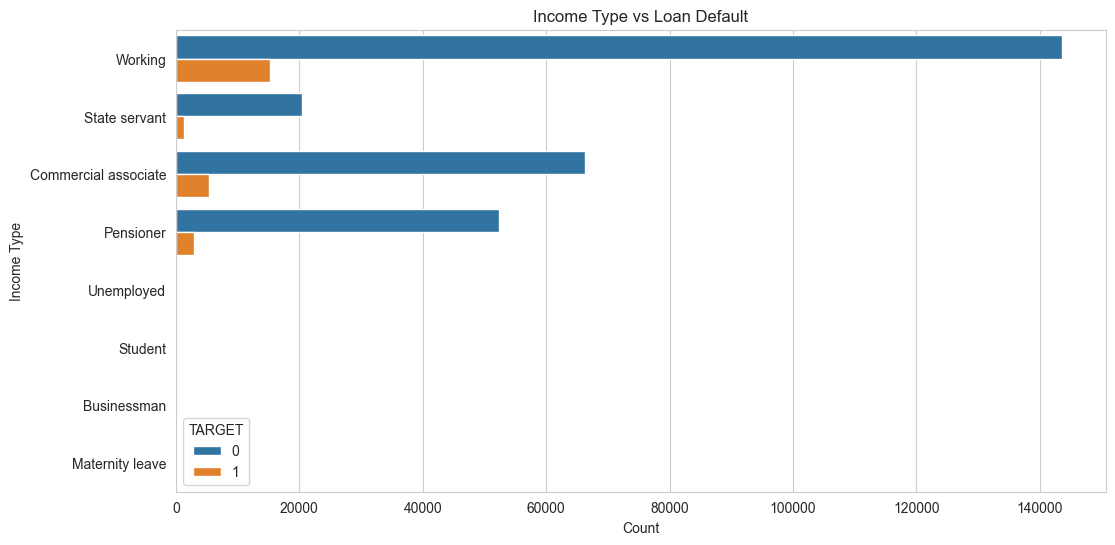

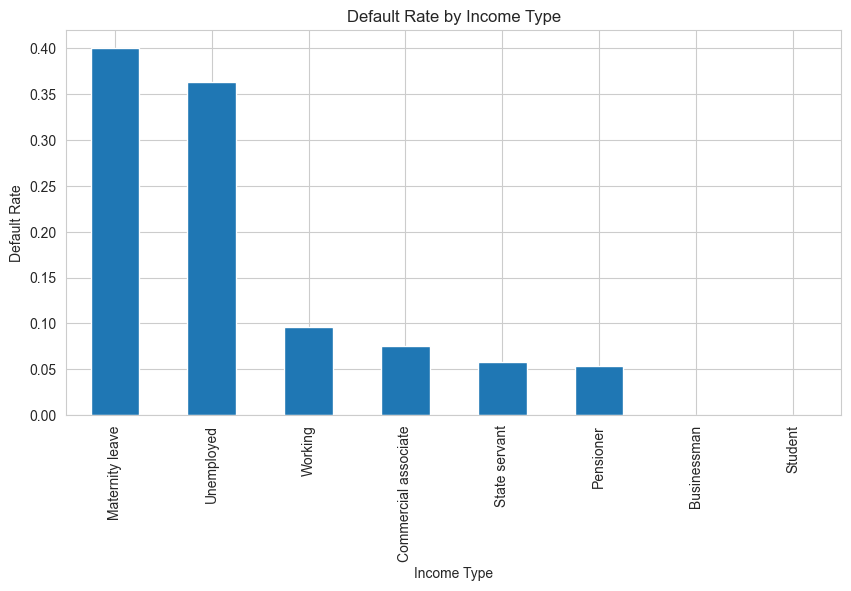


Business Insight:
Income type significantly influences repayment behavior, with certain employment categories 
showing higher default tendencies than others.



In [35]:
df["NAME_INCOME_TYPE"].value_counts()

plt.figure(figsize=(12,6))

sns.countplot(
    y="NAME_INCOME_TYPE",
    hue="TARGET",
    data=df
)

plt.title("Income Type vs Loan Default")
plt.xlabel("Count")
plt.ylabel("Income Type")

plt.savefig("../assets/charts/income_type_vs_default.png")

plt.show()

income_risk = (
    df.groupby("NAME_INCOME_TYPE")["TARGET"]
    .mean()
    .sort_values(ascending=False)
)

income_risk

plt.figure(figsize=(10,5))

income_risk.plot(kind="bar")

plt.title("Default Rate by Income Type")
plt.xlabel("Income Type")
plt.ylabel("Default Rate")

plt.savefig("../assets/charts/default_rate_income_type.png")

plt.show()

print("""
Business Insight:
Income type significantly influences repayment behavior, with certain employment categories 
showing higher default tendencies than others.
""")

In [36]:
df["CREDIT_INCOME_RATIO"] = (
    df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
)

/var/folders/zl/6dwxxfl91wgf183y1zsxyhym0000gn/T/ipykernel_4936/4268932025.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["CREDIT_INCOME_RATIO"] = (


In [37]:
df["CREDIT_INCOME_RATIO"].describe()

count    307511.000000
mean          3.957570
std           2.689728
min           0.004808
25%           2.018667
50%           3.265067
75%           5.159880
max          84.736842
Name: CREDIT_INCOME_RATIO, dtype: float64

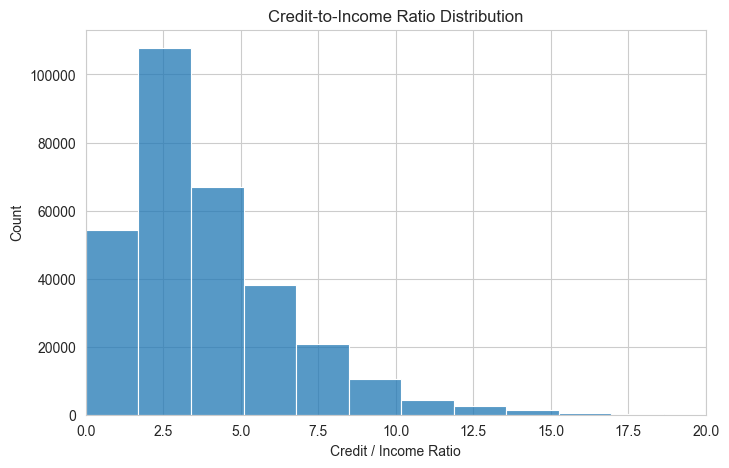

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["CREDIT_INCOME_RATIO"],
    bins=50
)

plt.xlim(0, 20)

plt.title("Credit-to-Income Ratio Distribution")
plt.xlabel("Credit / Income Ratio")
plt.ylabel("Count")

plt.savefig("../assets/charts/credit_income_ratio_distribution.png")

plt.show()

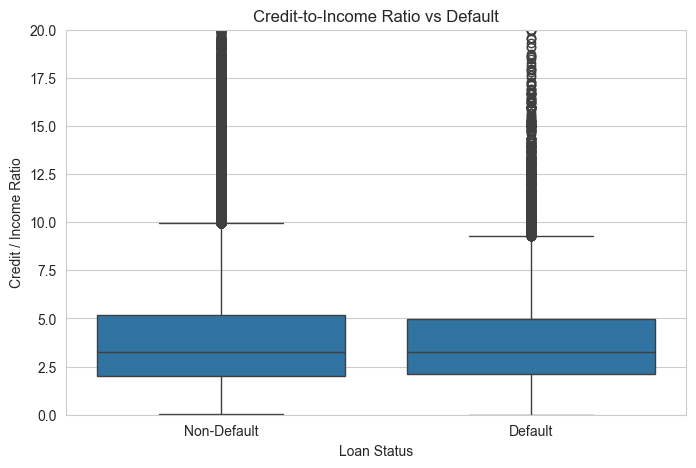

In [39]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="TARGET",
    y="CREDIT_INCOME_RATIO",
    data=df
)

plt.ylim(0, 20)

plt.title("Credit-to-Income Ratio vs Default")
plt.xlabel("Loan Status")
plt.ylabel("Credit / Income Ratio")

plt.xticks([0,1], ["Non-Default", "Default"])

plt.savefig("../assets/charts/credit_income_ratio_vs_default.png")

plt.show()

In [40]:
print("""
Business Insight:
Applicants with higher credit-to-income ratios exhibit significantly higher default tendencies, 
indicating repayment burden is a major driver of credit risk.
""")


Business Insight:
Applicants with higher credit-to-income ratios exhibit significantly higher default tendencies, 
indicating repayment burden is a major driver of credit risk.



In [41]:
df["ANNUITY_INCOME_RATIO"] = (
    df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
)

/var/folders/zl/6dwxxfl91wgf183y1zsxyhym0000gn/T/ipykernel_4936/2304178591.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ANNUITY_INCOME_RATIO"] = (


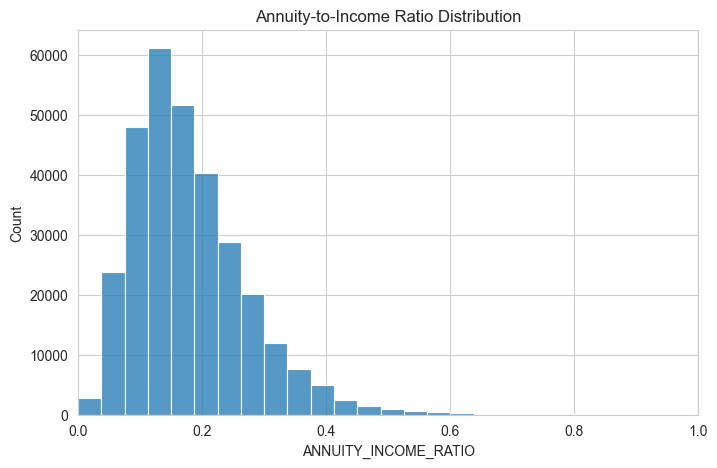

In [42]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["ANNUITY_INCOME_RATIO"],
    bins=50
)

plt.xlim(0, 1)

plt.title("Annuity-to-Income Ratio Distribution")

plt.savefig("../assets/charts/annuity_income_ratio_distribution.png")

plt.show()

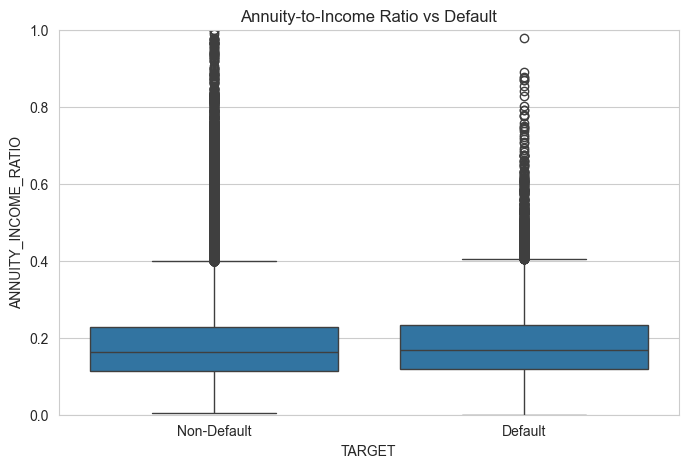

In [43]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="TARGET",
    y="ANNUITY_INCOME_RATIO",
    data=df
)

plt.ylim(0, 1)

plt.title("Annuity-to-Income Ratio vs Default")

plt.xticks([0,1], ["Non-Default", "Default"])

plt.savefig("../assets/charts/annuity_income_ratio_vs_default.png")

plt.show()

In [ ]:
print("""
Business Insight:
Higher annuity-to-income ratios are associated with elevated default probability, 
indicating repayment affordability is a critical credit risk factor.
""")

In [44]:
processed = pd.read_parquet(
    "../data/processed/application_processed.parquet"
)

processed.head()

,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,...,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,HOUSETYPE_MODE_specific housing,HOUSETYPE_MODE_terraced house,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Wooden,TARGET
0,-0.324395,-0.717914,0.664531,-0.623536,0.655160,-0.220419,-0.164393,-0.273155,-0.144308,1.506880,...,2.218375,-0.069989,-0.062904,-0.086733,-0.076281,-0.072886,-0.522963,1.935056,-0.133215,1
1,-0.324395,-0.717914,-1.504820,-0.623536,1.260100,1.419719,0.641054,1.379129,-1.269054,-0.166821,...,-0.450780,-0.069989,-0.062904,-0.086733,-0.076281,-0.072886,-0.522963,-0.516781,-0.133215,0
2,3.082659,1.392925,0.664531,-0.623536,-1.654998,-1.782978,-1.479012,-1.623983,-0.788555,-0.689509,...,-0.450780,-0.069989,-0.062904,-0.086733,-0.076281,-0.072886,-0.522963,-0.516781,-0.133215,0
3,-0.324395,-0.717914,0.664531,-0.623536,-0.197453,-0.592633,0.200761,-0.509324,-0.937237,-0.680114,...,2.218375,-0.069989,-0.062904,-0.086733,-0.076281,-0.072886,-0.522963,-0.516781,-0.133215,0
4,-0.324395,-0.717914,0.664531,-0.623536,-0.419005,0.109019,-0.372016,0.263339,0.573648,-0.892535,...,-0.450780,-0.069989,-0.062904,-0.086733,-0.076281,-0.072886,-0.522963,-0.516781,-0.133215,0
